I used Google Colab’s file upload tool to open a file picker and manually upload a dataset from my computer into the Colab environment so I could use it in my analysis.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving ADA_Barriers_in_the_Public_Right_of_Way.csv to ADA_Barriers_in_the_Public_Right_of_Way.csv


I cleaned the ASSET_TYPE column by first removing any missing values so they wouldn’t interfere with the analysis. Then I stripped extra spaces and standardized all text to uppercase so that similar barrier types would be grouped correctly. After that, I counted how many times each barrier type appears in the dataset.

In [6]:
import pandas as pd

df_barriers = pd.read_csv('ADA_Barriers_in_the_Public_Right_of_Way.csv')

df_barriers = df_barriers.dropna(subset=['ASSET_TYPE'])

df_barriers['ASSET_TYPE'] = df_barriers['ASSET_TYPE'].str.strip().str.upper()

asset_counts = df_barriers['ASSET_TYPE'].value_counts()
asset_table = asset_counts.reset_index()
asset_table.columns = ['ASSET_TYPE', 'COUNT']

asset_table

,ASSET_TYPE,COUNT
0,VERTICAL DISPLACEMENT,2463
1,HORIZONTAL DISPLACEMENT,1438
2,SIDEWALK ENDS,1365
3,NO SIDEWALK,1338
4,SIDEWALK CRACKED,702
...,...,...
474,SIDEWALK ENDS/ MISSING,1
475,RECYCLING CAN,1
476,SIDEWAK ENDS,1
477,EMPTY TREE BED,1


I created a grouping function to consolidate the ASSET_TYPE column into broader, more meaningful categories. This function groups similar barrier descriptions together, such as vertical and horizontal displacements, cracked sidewalks, missing sidewalks, vegetation-related obstructions, signage issues, and trash-related items. It also combines multiple variations of similar terms (like trash and garbage) into unified categories. Any entries that don’t match these defined patterns are grouped into a general “miscellaneous” category. After defining the grouping logic, I applied it to create a new grouped column, counted the frequency of each category, converted the results into a table, and displayed the top 11 most common barrier types.

In [7]:
import pandas as pd


def group_asset(x):
    if 'VERTICAL' in x:
        return 'VERTICAL DISPLACEMENT'
    elif 'HORIZONTAL' in x:
        return 'HORIZONTAL DISPLACEMENT'
    elif 'CRACK' in x:
        return 'CRACKED SIDEWALK'
    elif 'MISSING' in x:
        return 'NO SIDEWALK'
    elif 'PAR' in x:
        return 'POOR PAR'
    elif 'POLE' in x:
        return 'POLE'
    elif 'TRASH' in x or 'GARBAGE' in x:
        return 'TRASH'
    elif 'NO WIDTH' in x or 'NO SIDE WITH' in x or 'END' in x:
        return 'POOR WIDTH'
    elif 'SIGN' in x:
        return 'SIGN'
    elif 'TREE' in x or 'GRASS' in x or 'PLANTS' in x or 'VEGETATION' in x:
        return 'VEGETATION OBSTRUCTION'
    else:
        return 'MISCELLANEOUS'

df_barriers['ASSET_TYPE_GROUPED'] = df_barriers['ASSET_TYPE'].apply(group_asset)

grouped_counts = df_barriers['ASSET_TYPE_GROUPED'].value_counts()

grouped_table = grouped_counts.reset_index()
grouped_table.columns = ['ASSET_TYPE', 'COUNT']

top11 = grouped_table.head(11)

top11

,ASSET_TYPE,COUNT
0,VERTICAL DISPLACEMENT,2796
1,MISCELLANEOUS,2436
2,POOR WIDTH,1746
3,HORIZONTAL DISPLACEMENT,1704
4,CRACKED SIDEWALK,1309
5,POOR PAR,847
6,POLE,801
7,VEGETATION OBSTRUCTION,401
8,NO SIDEWALK,350
9,TRASH,232


I created a bar chart to visualize the distribution of grouped ADA barrier types in the dataset. I sorted the category counts in descending order so the most common barrier types would appear first and make the chart easier to read.

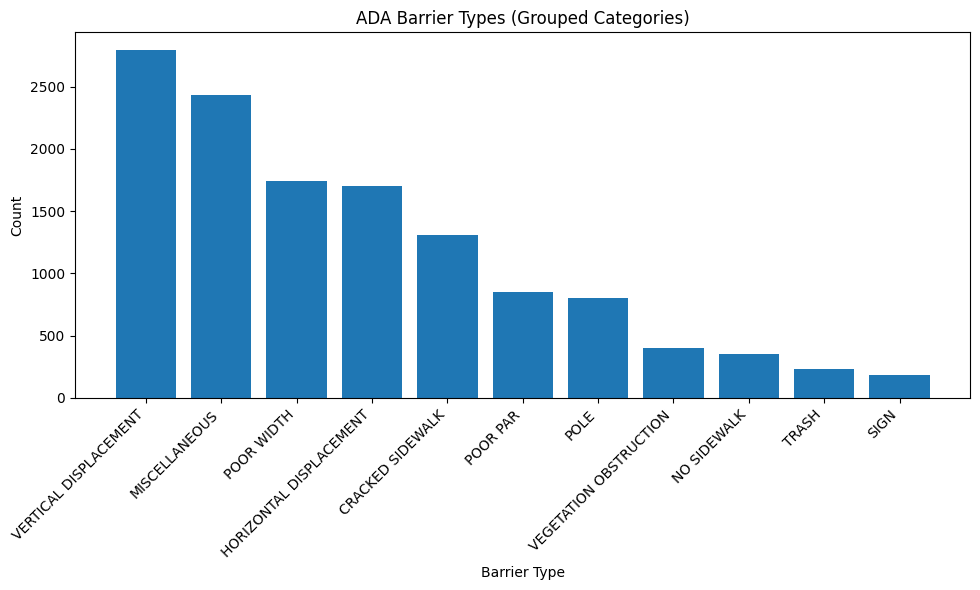

In [8]:
import matplotlib.pyplot as plt

plot_data = grouped_counts.sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(plot_data.index, plot_data.values)

plt.title('ADA Barrier Types (Grouped Categories)')
plt.xlabel('Barrier Type')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

I cleaned the grouped ADA barrier data by replacing any missing values in the ASSET_TYPE_GROUPED column with “OTHER” so that no entries were left undefined. Then I created a classification system that organizes barrier types into three levels of impact based on how severely they affect pedestrian accessibility. I defined a high-impact category for barriers that significantly block or prevent access, such as missing sidewalks and structural displacements. I defined a medium-impact category for issues like cracked sidewalks and poor pedestrian accessibility features. Finally, I defined a low-impact category for smaller obstructions like poles, signs, trash, and vegetation that may hinder movement but are generally less severe than structural barriers.

In [9]:
df_barriers['ASSET_TYPE_GROUPED'] = df_barriers['ASSET_TYPE_GROUPED'].fillna('OTHER')

high_impact = [
    'NO SIDEWALK',
    'POOR WIDTH',
    'VERTICAL DISPLACEMENT',
    'HORIZONTAL DISPLACEMENT']

medium_impact = [
    'CRACKED SIDEWALK',
    'POOR PAR']

low_impact = [
    'POLE',
    'SIGN',
    'TRASH',
    'VEGETATION OBSTRUCTION']

I created a function to assign each ADA barrier type to an impact level based on how much it affects pedestrian accessibility. I then applied this function to classify each entry as high, medium, low, or miscellaneous by comparing it to predefined impact categories.

In [10]:
impact_map = {
    'NO SIDEWALK': 'HIGH IMPACT',
    'POOR WIDTH': 'HIGH IMPACT',
    'VERTICAL DISPLACEMENT': 'HIGH IMPACT',
    'HORIZONTAL DISPLACEMENT': 'HIGH IMPACT',
    'CRACKED SIDEWALK': 'MEDIUM IMPACT',
    'POOR PAR': 'MEDIUM IMPACT',
    'POLE': 'LOW IMPACT',
    'SIGN': 'LOW IMPACT',
    'TRASH': 'LOW IMPACT',
    'VEGETATION OBSTRUCTION': 'LOW IMPACT'
}

df_barriers['IMPACT_LEVEL'] = df_barriers['ASSET_TYPE_GROUPED'].map(impact_map).fillna('MISCELLANEOUS')

In [11]:
impact_counts = df_barriers['IMPACT_LEVEL'].value_counts()
impact_counts

,count
IMPACT_LEVEL,
HIGH IMPACT,6596
MISCELLANEOUS,2436
MEDIUM IMPACT,2156
LOW IMPACT,1616


I sorted the barrier types by how often they appear. Then I matched each barrier type to its impact level and gave each level a color. I made a bar chart using those colors so each bar shows its impact level. I also added a legend to explain what each color means.

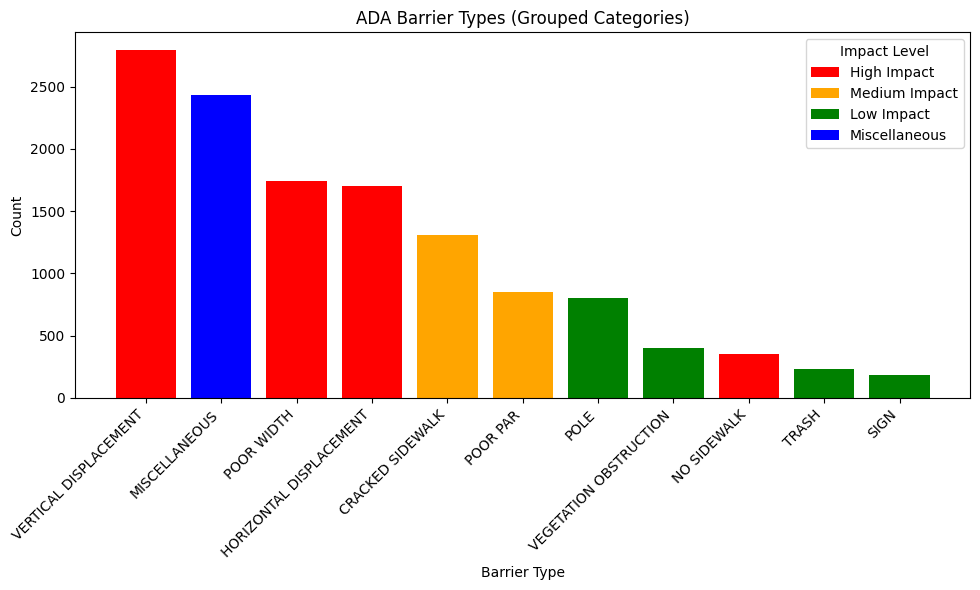

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plot_data = grouped_counts.sort_values(ascending=False)

category_impact = df_barriers.drop_duplicates('ASSET_TYPE_GROUPED') \
    .set_index('ASSET_TYPE_GROUPED')['IMPACT_LEVEL']

impact_colors = {
    'HIGH IMPACT': 'red',
    'MEDIUM IMPACT': 'orange',
    'LOW IMPACT': 'green',
    'MISCELLANEOUS': 'blue'
}

colors = [impact_colors.get(category_impact.get(cat, 'MISCELLANEOUS'))
          for cat in plot_data.index]

plt.figure(figsize=(10,6))
plt.bar(plot_data.index, plot_data.values, color=colors)

plt.title('ADA Barrier Types (Grouped Categories)')
plt.xlabel('Barrier Type')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')

legend_elements = [
    Patch(facecolor='red', label='High Impact'),
    Patch(facecolor='orange', label='Medium Impact'),
    Patch(facecolor='green', label='Low Impact'),
    Patch(facecolor='blue', label='Miscellaneous')
]
plt.legend(handles=legend_elements, title='Impact Level')

plt.tight_layout()
plt.show()